## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

In [1]:
## Define & Measure
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "garrettspringsted"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("/content/STAT-7110-Quality-Control/Assignments/HW2")
getwd()
list.files()

[1] "/content/STAT-7110-Quality-Control/Assignments/HW2"

[1] "BustersSportsBar_PhaseI.xlsx"  "BustersSportsBar_PhaseII.xlsx"
[3] "STAT-7110-HW2.ipynb"

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

### A1: The purpose of this analysis it to determine whether Buster"s beer pouring process is stable and is consistently meeting the pour-volume tolerance, ensuring consistent liquid to head ratio per beer pour. It also aims to establush a monitoring plan to detect gradual changes in pour volume as the CO2 regulator ages.



### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

###A2: The quality characteristic that is being monitored is the volume of beer poured per pint. The beer is being measured in ounces and is considered a continuous variable measured on a ratio scale.



### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

### A3: A CUSUM and EWMA chart would be appropriate for this scenario because they are both sensitive to small changes or shifts in the process mean. They wouls more easily be able to identify the gradual decrease in the pour volume that occurs as the CO2 regulator ages. Both CUSUM and EWMA charts can use the information from the sequence of observations rather than relying on the most recent points. A limitation of CUSUM is that it is a bit more complex to use and interpret. Specifically the selection of $H$ and $K$. A limitation of EWMA is that it assumes observations are independent, and correlated observations can negatively affect the charts ARL performance.



## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

## A4: The Phase 1 data consists of 25 shifts with 5 pours per shift. The subgroup mean and ranges were calculated for each shift to guage the average pour volume and variablity within each shift. Across the Phase 1 data, the estimated process mean was 16.0386 oz, and with an estimated process standard deviation of 0.0753 oz. Shift 12 does appear noticeably different from the other shifts with a low subgroup mean.

In [2]:
## Read in Phase 1 Data ##
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

buster1<- read_xlsx("BustersSportsBar_PhaseI.xlsx")
buster1 |> glimpse()

## Subgroup Means##
buster1_means<-rowMeans(buster1[,2:6])
buster1_means

## Subgroup Ranges##
buster1_ranges<- apply(buster1[,2:6],1, function(x) max(x)-min(x))
buster1_ranges

buster1_means
buster1_ranges

##Process Mean##
mu_hat <-mean(buster1_means)

#Process SD##
sigma_hat<-sd.xbar(buster1[, 2:6], std.dev = "UWAVE-SD")

mu_hat
sigma_hat

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…


[1] 16.08904 16.05598 16.05138 16.06778 15.98750 16.03776 16.05344 16.09518
 [9] 16.06680 16.04824 16.04584 15.70784 16.07864 16.06210 16.00644 16.04154
[17] 16.05512 16.08314 15.99566 16.02050 16.10078 16.02546 16.09228 16.03506
[25] 16.06046

[1] 0.2469 0.0783 0.0801 0.1791 0.0641 0.2016 0.1548 0.2202 0.1927 0.0942
[11] 0.1200 0.2178 0.1995 0.1993 0.1643 0.1941 0.1180 0.1488 0.6818 0.0912
[21] 0.0724 0.1377 0.2165 0.2231 0.1919

[1] 16.08904 16.05598 16.05138 16.06778 15.98750 16.03776 16.05344 16.09518
 [9] 16.06680 16.04824 16.04584 15.70784 16.07864 16.06210 16.00644 16.04154
[17] 16.05512 16.08314 15.99566 16.02050 16.10078 16.02546 16.09228 16.03506
[25] 16.06046

[1] 0.2469 0.0783 0.0801 0.1791 0.0641 0.2016 0.1548 0.2202 0.1927 0.0942
[11] 0.1200 0.2178 0.1995 0.1993 0.1643 0.1941 0.1180 0.1488 0.6818 0.0912
[21] 0.0724 0.1377 0.2165 0.2231 0.1919

[1] 16.03856

[1] 0.07532586

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

##A5: The intial $R$ Chart indicates that the process variablity is not in statistical control. Shift 19 is above the upper control limit of 0.3796234, with a subgroup range of ~0.6818 oz, this indicates a greater variation among the five pours during that shift than what was observed during the other shifts. This flags a possible inconsistency in the pouring process whether it is equipment or operator error. Shift 19 will be removed and the $R$ Chart will be recalculated.

## After recalculating with Chift 19 removed, the clean chart had a center line of 0.1586 oz, an UCL of 0.3354 oz, and an LCL of 0 oz. No remaining subgroup exceeded the control limits or violated the run rules, indicating that the process variability was in statistical control after removing Shift 19.

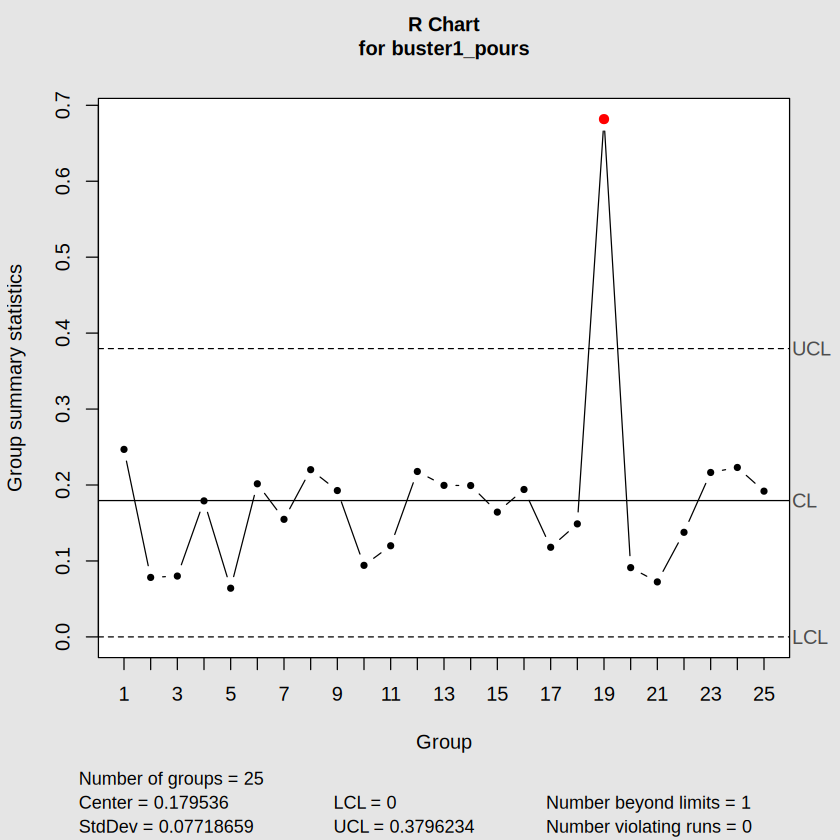

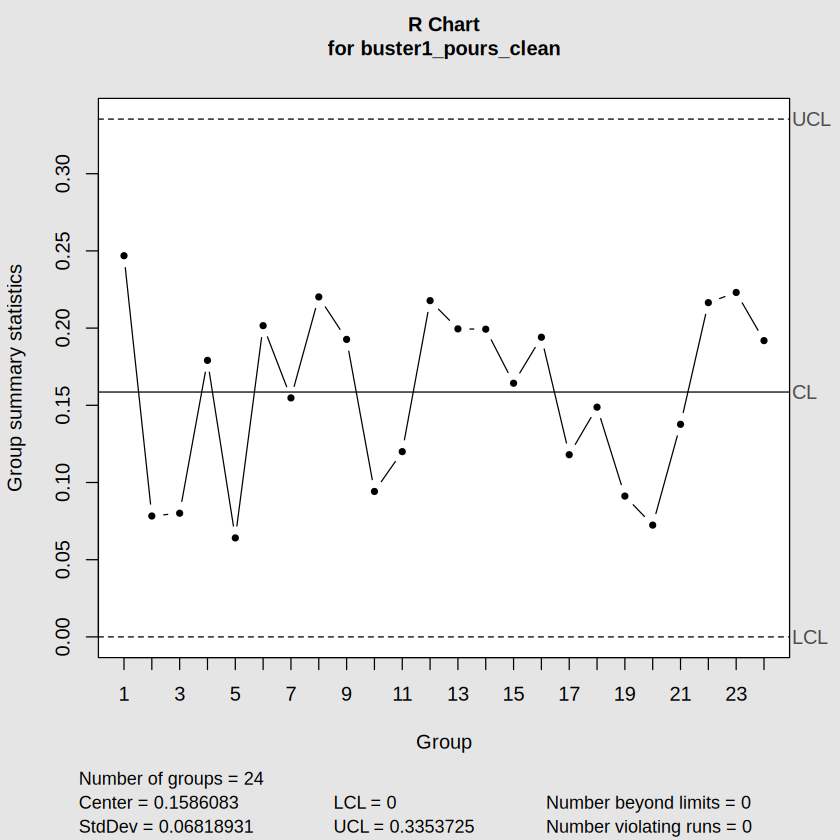

In [3]:
## Five Pours##
buster1_pours<-buster1[, 2:6]

##R chart##
buster1_R <-qcc(buster1_pours, type="R")

##Plot##
plot(buster1_R)

##Remove 19##
buster1_pours_clean <-buster1[-19, 2:6]

##R chart##
buster1_R_clean <-qcc(buster1_pours_clean, type="R")

##Plot##
plot(buster1_R_clean)


### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

###A6: After using the inital $\bar{X}$ using the retained subgroups from the $R$ Chart analysis, it indicated that the process mean was not in statistical control. SHift 12 fell well below the LCL. The subgroup mean dor shift 12 was ~15.7078 oz, which indicated that the average pour voume during this shift was lower than expected. This may represent a temnporary change in CO2 pressure, equioment behavior, or the pouring process. I then removed SHift 12 fromt he Phase 1 baseline and recalculated the $\bar{X}$ chart. After removal the new chart had a centerline of 16.0548 oz, an LCL of 15.9648 oz, and an UCL of 16.1448 oz. No other subgroups exceeded the control limits or violated the run rules, indicating that the process mean is now in statistical control.

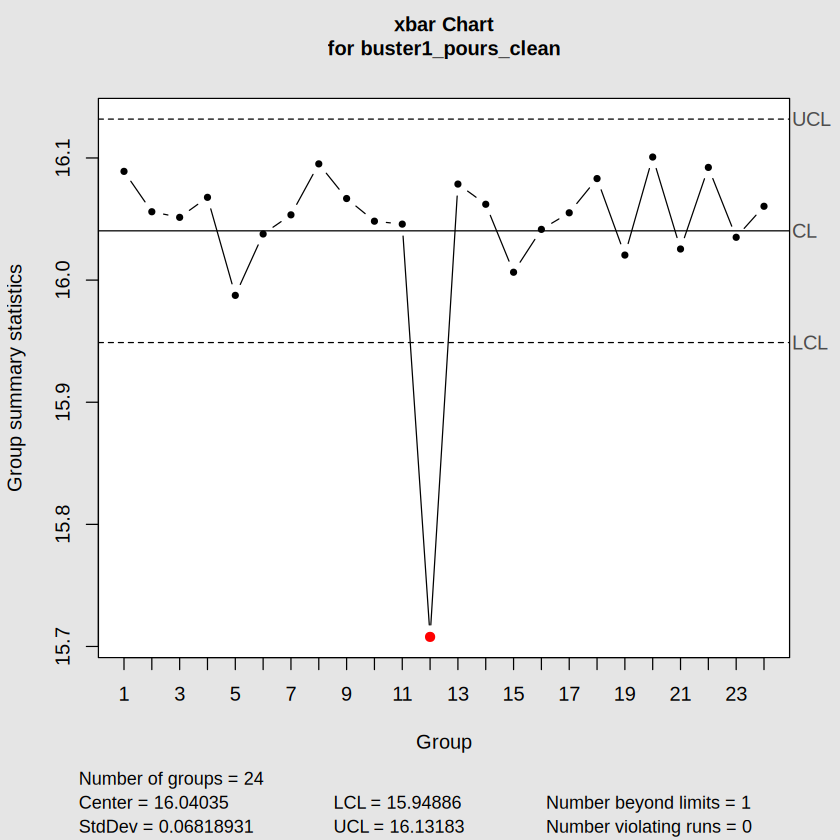

[1] 16.0548

[1] 0.06708288

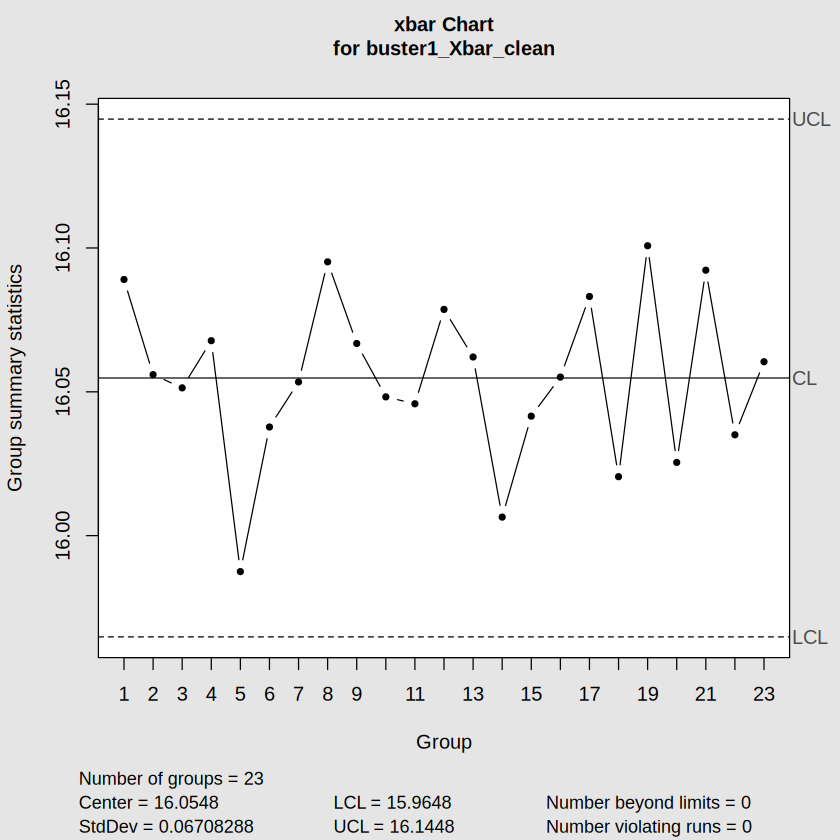

In [15]:
##X Bar CHart for Phase 1 ##
buster1_Xbar <- qcc(buster1_pours_clean, type="xbar")

plot(buster1_Xbar)

## 12 is out of control so removal will happen##

buster1_Xbar_clean<-buster1_pours_clean[-12,]

##Plot again##

buster1_Xbar_final<-qcc(buster1_Xbar_clean, type="xbar")

plot(buster1_Xbar_final)

mu_hat_buster <-mean(rowMeans(buster1_Xbar_clean))

sigma_hat_buster<-sd.xbar(buster1_Xbar_clean)

mu_hat_buster
sigma_hat_buster

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $PCR$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

###A7:Using the final Phase I estimates of the process mean and process standard deviation. The process capability analysis against the specification limits produced the following results. Results of $C_p$ = 0.994, $C_{pk}$ = 0.722, and $C_{pm}$ = 0.770. Because the process indices are below 1 and its reciprocal indicates that the process uses approximately 100.6% of the available specification band. The process is not capable of meeting the specification limits of 15.80 oz to 16.20 oz. The estimated process mean of 16.0548 oz is also above the target pour volume of 16.00 oz. The lower $C_{pk}$ compared to the $C_p$ tells us that the process is not well-centered with the process shifted toward the upper specification limit.

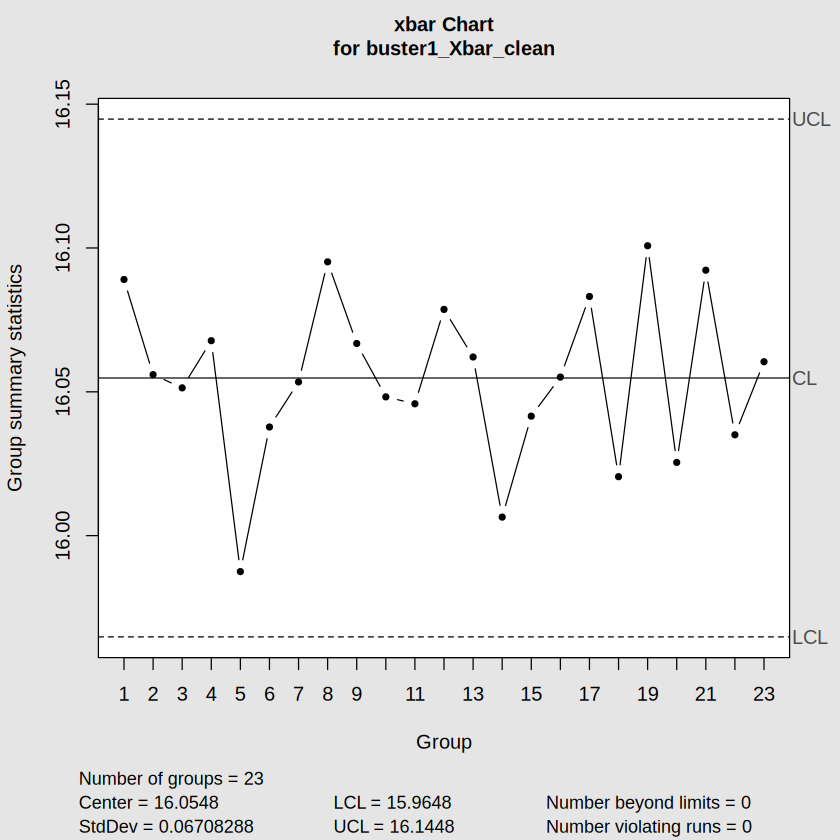


Process Capability Analysis

Call:
process.capability(object = buster1_capability, spec.limits = c(15.8,     16.2), target = 16, nsigmas = 3)

Number of obs = 115          Target = 16
       Center = 16.05           LSL = 15.8
       StdDev = 0.06708         USL = 16.2

Capability indices:

       Value    2.5%   97.5%
Cp    0.9938  0.8649  1.1225
Cp_l  1.2661  1.1190  1.4132
Cp_u  0.7215  0.6277  0.8152
Cp_k  0.7215  0.6098  0.8332
Cpm   0.7696  0.6521  0.8870

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 1.5%	 Obs>USL 2.6%


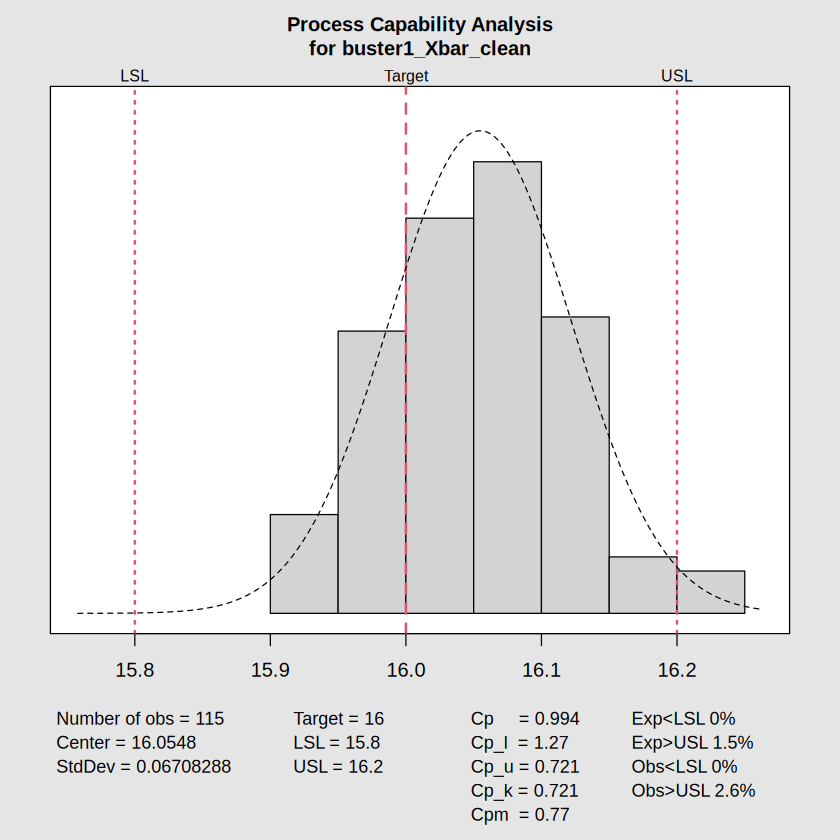

In [18]:
buster1_capability<-qcc(
  buster1_Xbar_clean,
  type="xbar",
  std.dev=sigma_hat_buster,
  plot=TRUE
)

process.capability(
  buster1_capability,
  spec.limits = c(15.80, 16.20),
  target = 16.00,
  nsigmas=3
)

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

###A8:The monitoring scheme that detects about one process Standard deviation. Based on the Phase 1 estimate of $\sigma$= 0.06708, a one standard dviation shift is ~ 0.06708 oz in the process mean. For the CUSUM chart, I selected $K$ =0.5 and $H$= 5. The $K$ value is for detecting ta shift of 1$\sigma$, while $H$=5 results in an in-control ARL of approximately 465, which falls within the desired range of 370-500. For the EWMA chart I selected $\lambda$=0.10 and $L$=2.824. This combonation has an in-control ARL of approximately 500 and an ARL of approximately 10.3 for 1$\sigma$ shift. This provides sensisitivity to the small changes expected from the regulator shift at an early stage.



## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [6]:
## Q9 Code ##

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [7]:
## Q10 Code ##

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

In [8]:
## Q11 Code ##

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?